# 学習・テストデータ確認

このノートブックでは、以下の分析を行います：
- `check_data/train_doc_ids.tsv` から `train_end_date` の年（yyyy）を抽出し、年ごとの件数をカウント
- `check_data/test_doc_ids.tsv` から `test_end_date` の年（yyyy）を抽出し、年ごとの件数をカウント
- 訓練データとテストデータの年別分布を比較・可視化

## 1. ライブラリのインポート

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import numpy as np
import japanize_matplotlib

from matplotlib import rcParams
rcParams['font.family'] = 'IPAexGothic'
# Matplotlibの日本語表示設定
# sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

## 2. データの読み込み

In [3]:
# TSVファイルのパスを設定
data_path = Path('../data/train_doc_ids.tsv')

# TSVファイルを読み込み
df = pd.read_csv(data_path, sep='\t')

print(f"データ形状: {df.shape}")
print(f"\nカラム名: {list(df.columns)}")
print("\n最初の5行:")
df.head()

データ形状: (549, 5)

カラム名: ['train_company_name', 'train_start_date', 'train_end_date', 'prev_year_doc_id', 'current_year_doc_id']

最初の5行:


,train_company_name,train_start_date,train_end_date,prev_year_doc_id,current_year_doc_id
0,ナトコ株式会社,2016-11-01,2017-10-31,S100C62H,S100EZZ0
1,株式会社エプコ,2017-01-01,2017-12-31,S100CMEU,S100FHX0
2,第一稀元素化学工業株式会社,2018-04-01,2019-03-31,S100G7KY,S100IWL6
3,和弘食品株式会社,2016-04-01,2017-03-31,S100AIUS,S100D9G3
4,ユニチカ株式会社,2018-04-01,2019-03-31,S100G9RN,S100J0TD


## 3. データの基本情報確認

In [4]:
# データの基本情報
print("データの基本情報:")
df.info()

print("\n欠損値の確認:")
print(df.isnull().sum())

print("\ntrain_end_dateの例:")
print(df['train_end_date'].head(10))

データの基本情報:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 549 entries, 0 to 548
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   train_company_name   549 non-null    object
 1   train_start_date     549 non-null    object
 2   train_end_date       549 non-null    object
 3   prev_year_doc_id     549 non-null    object
 4   current_year_doc_id  549 non-null    object
dtypes: object(5)
memory usage: 21.6+ KB

欠損値の確認:
train_company_name     0
train_start_date       0
train_end_date         0
prev_year_doc_id       0
current_year_doc_id    0
dtype: int64

train_end_dateの例:
0    2017-10-31
1    2017-12-31
2    2019-03-31
3    2017-03-31
4    2019-03-31
5    2020-03-31
6    2016-06-30
7    2018-12-31
8    2017-12-31
9    2016-03-31
Name: train_end_date, dtype: object


## 4. 年（yyyy）の抽出

In [5]:
# train_end_dateから年を抽出
df['train_end_year'] = pd.to_datetime(df['train_end_date']).dt.year

print("年の抽出結果:")
print(df[['train_end_date', 'train_end_year']].head(10))

print(f"\n年の範囲: {df['train_end_year'].min()} - {df['train_end_year'].max()}")

年の抽出結果:
  train_end_date  train_end_year
0     2017-10-31            2017
1     2017-12-31            2017
2     2019-03-31            2019
3     2017-03-31            2017
4     2019-03-31            2019
5     2020-03-31            2020
6     2016-06-30            2016
7     2018-12-31            2018
8     2017-12-31            2017
9     2016-03-31            2016

年の範囲: 2016 - 2020


## 5. 年別件数の集計

In [6]:
# 年別件数の集計
year_counts = df['train_end_year'].value_counts().sort_index()

print("年別件数:")
print(year_counts)

print(f"\n総件数: {year_counts.sum()}")
print(f"年別平均件数: {year_counts.mean():.1f}")
print(f"年別件数の標準偏差: {year_counts.std():.1f}")

年別件数:
train_end_year
2016    103
2017    130
2018    106
2019    113
2020     97
Name: count, dtype: int64

総件数: 549
年別平均件数: 109.8
年別件数の標準偏差: 12.7


## 6. 年別件数の可視化

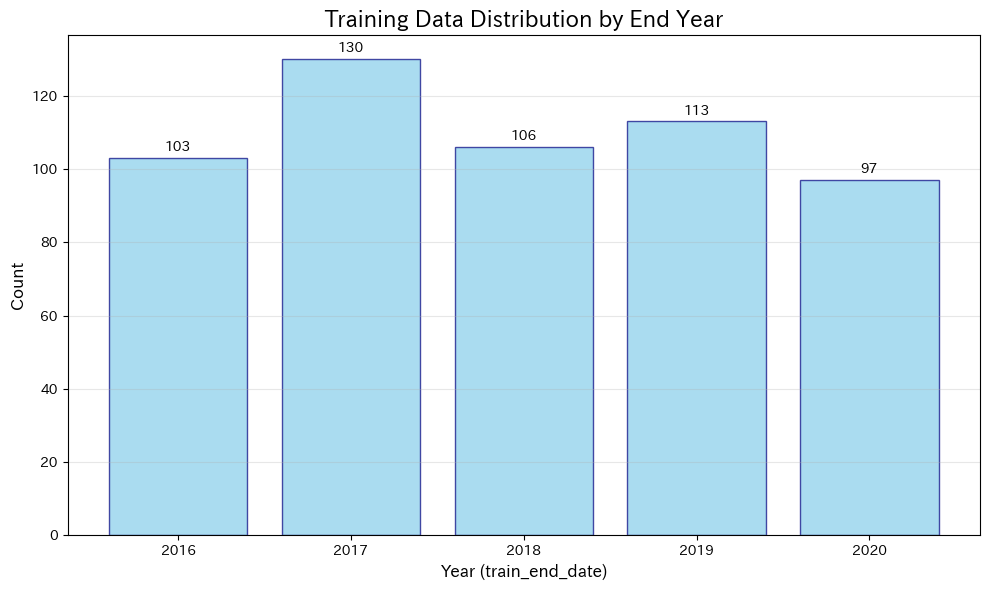

In [7]:
# バーチャートの作成
plt.figure(figsize=(10, 6))
bars = plt.bar(year_counts.index, year_counts.values, color='skyblue', edgecolor='navy', alpha=0.7)

# グラフの装飾
plt.title('Training Data Distribution by End Year', fontsize=16, fontweight='bold')
plt.xlabel('Year (train_end_date)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.grid(axis='y', alpha=0.3)

# 各バーの上に数値を表示
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{int(height)}', ha='center', va='bottom', fontweight='bold')

# x軸の年を整数で表示
plt.xticks(year_counts.index)
plt.tight_layout()
plt.show()

## 7. 統計サマリー

In [8]:
# 統計サマリーの作成
summary_stats = pd.DataFrame({
    '年': year_counts.index,
    '件数': year_counts.values,
    '割合(%)': (year_counts.values / year_counts.sum() * 100).round(1)
})

print("年別統計サマリー:")
print(summary_stats)

# 最大・最小件数の年を特定
max_year = year_counts.idxmax()
min_year = year_counts.idxmin()
max_count = year_counts.max()
min_count = year_counts.min()

print(f"\n\n=== データ分析結果 ===")
print(f"最多件数: {max_year}年 ({max_count}件)")
print(f"最少件数: {min_year}年 ({min_count}件)")
print(f"件数の差: {max_count - min_count}件")
print(f"データ期間: {year_counts.index.min()}年 - {year_counts.index.max()}年 ({len(year_counts)}年間)")

年別統計サマリー:
      年   件数  割合(%)
0  2016  103   18.8
1  2017  130   23.7
2  2018  106   19.3
3  2019  113   20.6
4  2020   97   17.7


=== データ分析結果 ===
最多件数: 2017年 (130件)
最少件数: 2020年 (97件)
件数の差: 33件
データ期間: 2016年 - 2020年 (5年間)


## 8. テストデータの読み込みと分析

In [9]:
# テストデータのTSVファイルを読み込み
test_data_path = Path('../data/test_doc_ids.tsv')
df_test = pd.read_csv(test_data_path, sep='\t')

print(f"テストデータ形状: {df_test.shape}")
print(f"\nカラム名: {list(df_test.columns)}")
print("\n最初の5行:")
df_test.head()

テストデータ形状: (451, 5)

カラム名: ['test_company_name', 'test_start_date', 'test_end_date', 'prev_year_doc_id', 'current_year_doc_id']

最初の5行:


,test_company_name,test_start_date,test_end_date,prev_year_doc_id,current_year_doc_id
0,コンピューターマネージメント株式会社,2020-04-01,2021-03-31,S100LP1H,S100OE2F
1,大平洋金属株式会社,2021-04-01,2022-03-31,S100OCRF,S100R3C1
2,サンコール株式会社,2022-04-01,2023-03-31,S100R2GZ,S100TTIW
3,株式会社商工組合中央金庫,2022-04-01,2023-03-31,S100R0DS,S100TMYJ
4,株式会社ファンケル,2022-04-01,2023-03-31,S100R2TJ,S100TOV4


## 9. テストデータの年別分析

In [10]:
# test_end_dateから年を抽出
df_test['test_end_year'] = pd.to_datetime(df_test['test_end_date']).dt.year

print("テストデータの年の抽出結果:")
print(df_test[['test_end_date', 'test_end_year']].head(10))

print(f"\nテストデータの年の範囲: {df_test['test_end_year'].min()} - {df_test['test_end_year'].max()}")

# テストデータの年別件数の集計
test_year_counts = df_test['test_end_year'].value_counts().sort_index()

print("\nテストデータ年別件数:")
print(test_year_counts)

print(f"\nテストデータ総件数: {test_year_counts.sum()}")
print(f"テストデータ年別平均件数: {test_year_counts.mean():.1f}")
print(f"テストデータ年別件数の標準偏差: {test_year_counts.std():.1f}")

テストデータの年の抽出結果:
  test_end_date  test_end_year
0    2021-03-31           2021
1    2022-03-31           2022
2    2023-03-31           2023
3    2023-03-31           2023
4    2023-03-31           2023
5    2021-09-30           2021
6    2023-03-31           2023
7    2022-12-31           2022
8    2021-03-31           2021
9    2023-03-31           2023

テストデータの年の範囲: 2020 - 2023

テストデータ年別件数:
test_end_year
2020      8
2021    132
2022    144
2023    167
Name: count, dtype: int64

テストデータ総件数: 451
テストデータ年別平均件数: 112.8
テストデータ年別件数の標準偏差: 71.3


## 10. テストデータの可視化

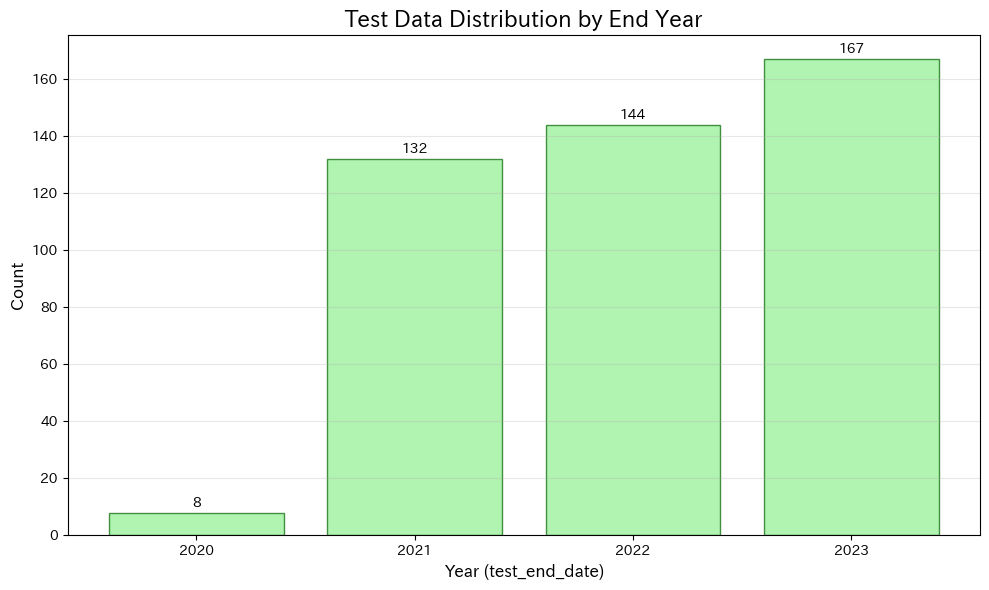

In [11]:
# テストデータのバーチャートの作成
plt.figure(figsize=(10, 6))
bars = plt.bar(test_year_counts.index, test_year_counts.values, color='lightgreen', edgecolor='darkgreen', alpha=0.7)

# グラフの装飾
plt.title('Test Data Distribution by End Year', fontsize=16, fontweight='bold')
plt.xlabel('Year (test_end_date)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.grid(axis='y', alpha=0.3)

# 各バーの上に数値を表示
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{int(height)}', ha='center', va='bottom', fontweight='bold')

# x軸の年を整数で表示
plt.xticks(test_year_counts.index)
plt.tight_layout()
plt.show()

## 11. 訓練データとテストデータの比較

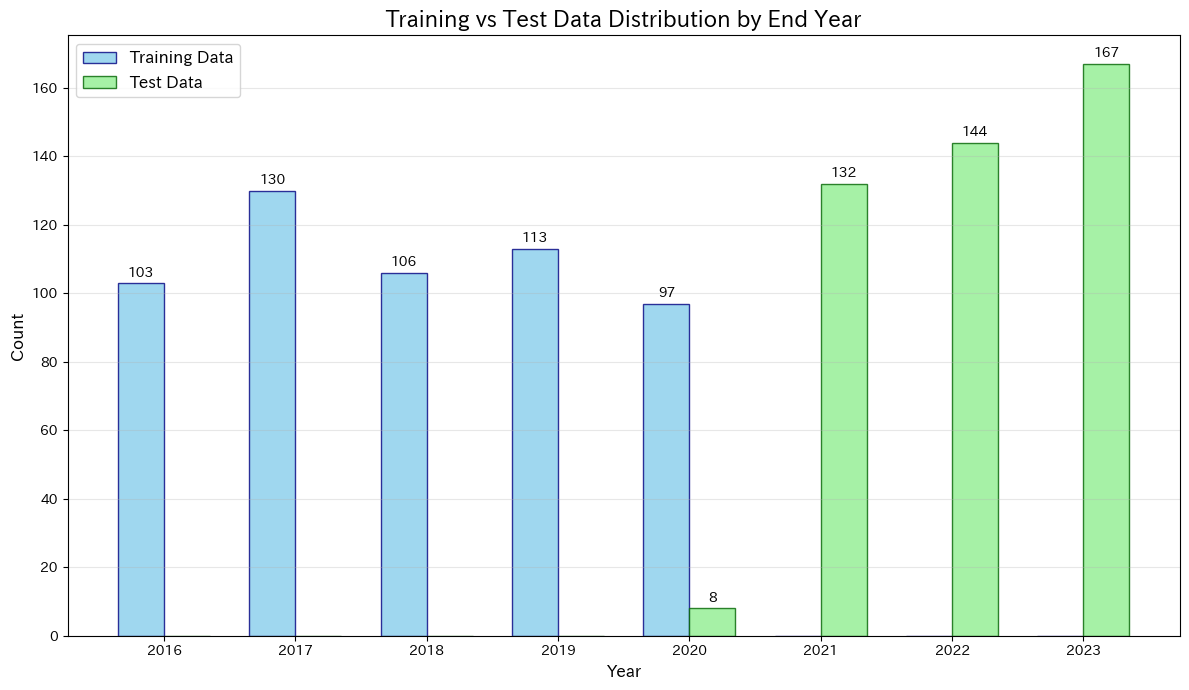

In [12]:
# 全体の年範囲を取得
all_years = sorted(set(list(year_counts.index) + list(test_year_counts.index)))

# 各年のデータを準備（存在しない年は0で埋める）
train_data = [year_counts.get(year, 0) for year in all_years]
test_data = [test_year_counts.get(year, 0) for year in all_years]

# 比較グラフの作成
x = range(len(all_years))
width = 0.35

plt.figure(figsize=(12, 7))
bars1 = plt.bar([i - width/2 for i in x], train_data, width, label='Training Data', color='skyblue', edgecolor='navy', alpha=0.8)
bars2 = plt.bar([i + width/2 for i in x], test_data, width, label='Test Data', color='lightgreen', edgecolor='darkgreen', alpha=0.8)

# グラフの装飾
plt.title('Training vs Test Data Distribution by End Year', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(x, all_years)
plt.legend(fontsize=12)
plt.grid(axis='y', alpha=0.3)

# 各バーの上に数値を表示
for bar in bars1:
    height = bar.get_height()
    if height > 0:  # 0の場合は表示しない
        plt.text(bar.get_x() + bar.get_width()/2., height + 1,
                 f'{int(height)}', ha='center', va='bottom', fontweight='bold', fontsize=10)

for bar in bars2:
    height = bar.get_height()
    if height > 0:  # 0の場合は表示しない
        plt.text(bar.get_x() + bar.get_width()/2., height + 1,
                 f'{int(height)}', ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

## 12. 訓練・テストデータの統計サマリー

In [13]:
# 統合されたサマリーテーブルを作成
comparison_df = pd.DataFrame({
    '年': all_years,
    '訓練データ件数': train_data,
    'テストデータ件数': test_data,
    '合計件数': [t + s for t, s in zip(train_data, test_data)]
})

print("年別データ分布比較:")
print(comparison_df)

print(f"\n=== 総合統計 ===")
print(f"訓練データ総件数: {sum(train_data)}件")
print(f"テストデータ総件数: {sum(test_data)}件")
print(f"全体総件数: {sum(train_data) + sum(test_data)}件")

print(f"\n訓練データ期間: {year_counts.index.min()}年 - {year_counts.index.max()}年")
print(f"テストデータ期間: {test_year_counts.index.min()}年 - {test_year_counts.index.max()}年")

# 重複年の確認
overlap_years = set(year_counts.index) & set(test_year_counts.index)
if overlap_years:
    print(f"\n重複年: {sorted(overlap_years)}")
    for year in sorted(overlap_years):
        train_count = year_counts.get(year, 0)
        test_count = test_year_counts.get(year, 0)
        print(f"  {year}年: 訓練 {train_count}件, テスト {test_count}件")
else:
    print("\n重複年: なし")

年別データ分布比較:
      年  訓練データ件数  テストデータ件数  合計件数
0  2016      103         0   103
1  2017      130         0   130
2  2018      106         0   106
3  2019      113         0   113
4  2020       97         8   105
5  2021        0       132   132
6  2022        0       144   144
7  2023        0       167   167

=== 総合統計 ===
訓練データ総件数: 549件
テストデータ総件数: 451件
全体総件数: 1000件

訓練データ期間: 2016年 - 2020年
テストデータ期間: 2020年 - 2023年

重複年: [2020]
  2020年: 訓練 97件, テスト 8件


## claudeはここから下を更新して

## 13. 業種分類データの読み込み

In [14]:
# 業種情報を含む詳細データの読み込み
train_full_path = Path('../data/train_doc_ids_with_fullinfo.tsv')
test_full_path = Path('../data/test_doc_ids_with_fullinfo.tsv')

# データの読み込み
df_train_full = pd.read_csv(train_full_path, sep='\t')
df_test_full = pd.read_csv(test_full_path, sep='\t')

print(f"学習データ（詳細）形状: {df_train_full.shape}")
print(f"テストデータ（詳細）形状: {df_test_full.shape}")

print("\n学習データのカラム名:")
print(list(df_train_full.columns))

print("\nテストデータのカラム名:")
print(list(df_test_full.columns))

学習データ（詳細）形状: (549, 14)
テストデータ（詳細）形状: (451, 14)

学習データのカラム名:
['train_company_name', 'train_start_date', 'train_end_date', 'prev_year_doc_id', 'current_year_doc_id', 'name_norm', 'コード', '市場・商品区分', '33業種コード', '33業種区分', '17業種コード', '17業種区分', '規模コード', '規模区分']

テストデータのカラム名:
['test_company_name', 'test_start_date', 'test_end_date', 'prev_year_doc_id', 'current_year_doc_id', 'name_norm', 'コード', '市場・商品区分', '33業種コード', '33業種区分', '17業種コード', '17業種区分', '規模コード', '規模区分']


## 14. 業種分類データの確認

In [15]:
# 業種関連カラムの基本情報確認
print("=== 学習データの業種情報 ===")
print("33業種区分の一覧:")
print(df_train_full['33業種区分'].value_counts().head(10))

print("\n17業種区分の一覧:")
print(df_train_full['17業種区分'].value_counts())

print("\n=== テストデータの業種情報 ===")
print("33業種区分の一覧:")
print(df_test_full['33業種区分'].value_counts().head(10))

print("\n17業種区分の一覧:")
print(df_test_full['17業種区分'].value_counts())

# 欠損値の確認
print(f"\n=== 欠損値確認 ===")
print(f"学習データ 33業種区分 欠損値: {df_train_full['33業種区分'].isnull().sum()}")
print(f"学習データ 17業種区分 欠損値: {df_train_full['17業種区分'].isnull().sum()}")
print(f"テストデータ 33業種区分 欠損値: {df_test_full['33業種区分'].isnull().sum()}")
print(f"テストデータ 17業種区分 欠損値: {df_test_full['17業種区分'].isnull().sum()}")

=== 学習データの業種情報 ===
33業種区分の一覧:
33業種区分
サービス業     47
情報・通信業    44
小売業       38
卸売業       36
機械        35
化学        30
電気機器      22
建設業       21
食料品       15
金属製品      14
Name: count, dtype: int64

17業種区分の一覧:
17業種区分
情報通信・サービスその他    102
素材・化学            45
建設・資材            41
小売               38
商社・卸売            36
機械               35
電機・精密            32
食品               17
自動車・輸送機          13
金融（除く銀行）         13
銀行               12
運輸・物流            12
不動産              12
鉄鋼・非鉄            11
医薬品              11
電力・ガス             3
エネルギー資源           2
Name: count, dtype: int64

=== テストデータの業種情報 ===
33業種区分の一覧:
33業種区分
サービス業     60
情報・通信業    57
小売業       37
卸売業       31
電気機器      23
化学        22
不動産業      19
機械        19
建設業       16
輸送用機器     15
Name: count, dtype: int64

17業種区分の一覧:
17業種区分
情報通信・サービスその他    129
小売               37
素材・化学            33
商社・卸売            31
建設・資材            30
電機・精密            29
機械               19
不動産              19
運輸・物流            17
自動車・輸送機          16
食品      

## 15. 33業種分類の可視化

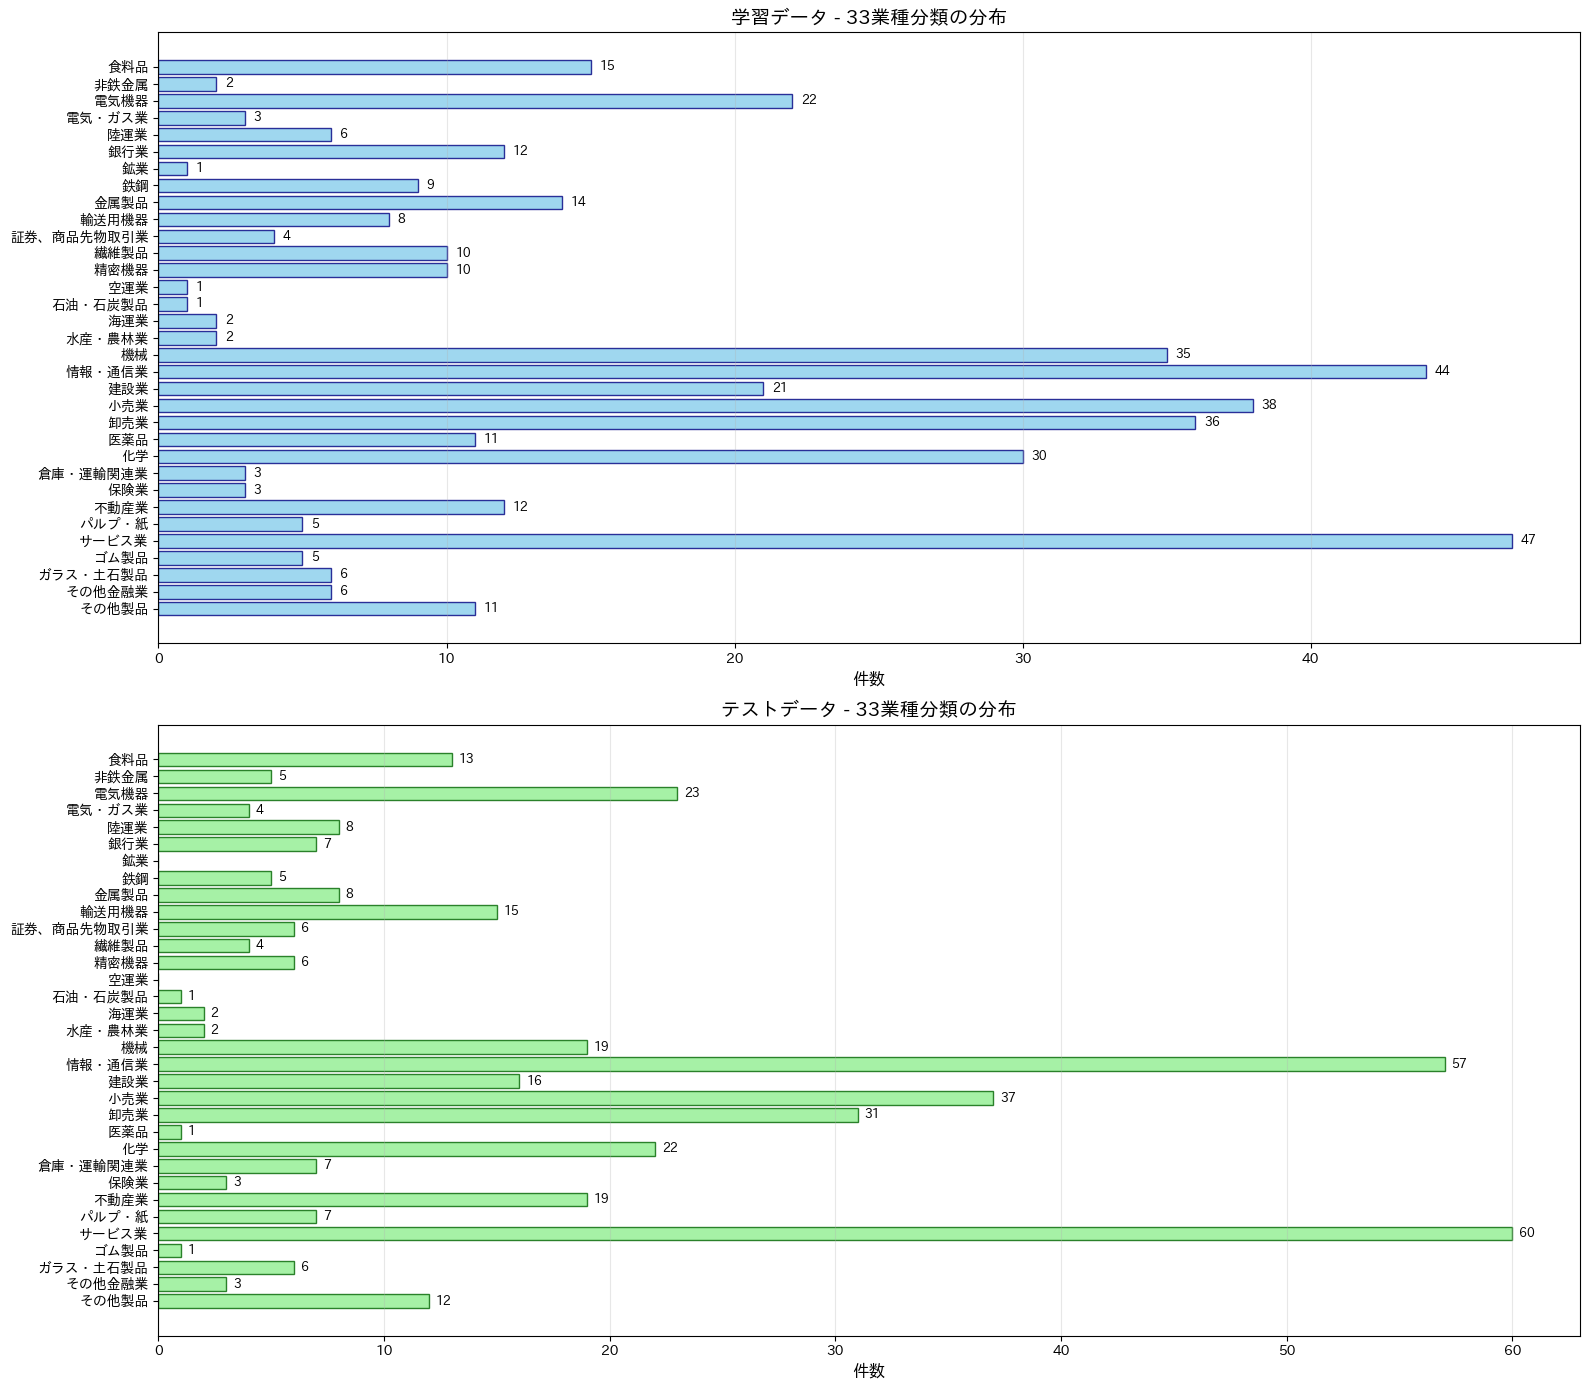

33業種分類の総数: 33種類
学習データに含まれる33業種数: 33種類
テストデータに含まれる33業種数: 31種類


In [16]:
# 33業種分類の件数集計
train_industry33 = df_train_full['33業種区分'].value_counts().fillna(0)
test_industry33 = df_test_full['33業種区分'].value_counts().fillna(0)

# 全ての業種を取得（学習・テスト両方含む）
all_industries33 = sorted(set(list(train_industry33.index) + list(test_industry33.index)))

# データを整形（存在しない業種は0で埋める）
train_counts33 = [train_industry33.get(industry, 0) for industry in all_industries33]
test_counts33 = [test_industry33.get(industry, 0) for industry in all_industries33]

# 33業種分類の比較グラフ作成
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 14))

# 学習データ
bars1 = ax1.barh(range(len(all_industries33)), train_counts33, color='skyblue', edgecolor='navy', alpha=0.8)
ax1.set_title('学習データ - 33業種分類の分布', fontsize=14, fontweight='bold')
ax1.set_xlabel('件数', fontsize=12)
ax1.set_yticks(range(len(all_industries33)))
ax1.set_yticklabels(all_industries33, fontsize=10)
ax1.grid(axis='x', alpha=0.3)

# 件数をバーの右側に表示
for i, bar in enumerate(bars1):
    width = bar.get_width()
    if width > 0:
        ax1.text(width + 0.3, bar.get_y() + bar.get_height()/2, 
                f'{int(width)}', ha='left', va='center', fontweight='bold', fontsize=9)

# テストデータ
bars2 = ax2.barh(range(len(all_industries33)), test_counts33, color='lightgreen', edgecolor='darkgreen', alpha=0.8)
ax2.set_title('テストデータ - 33業種分類の分布', fontsize=14, fontweight='bold')
ax2.set_xlabel('件数', fontsize=12)
ax2.set_yticks(range(len(all_industries33)))
ax2.set_yticklabels(all_industries33, fontsize=10)
ax2.grid(axis='x', alpha=0.3)

# 件数をバーの右側に表示
for i, bar in enumerate(bars2):
    width = bar.get_width()
    if width > 0:
        ax2.text(width + 0.3, bar.get_y() + bar.get_height()/2, 
                f'{int(width)}', ha='left', va='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

print(f"33業種分類の総数: {len(all_industries33)}種類")
print(f"学習データに含まれる33業種数: {len([x for x in train_counts33 if x > 0])}種類")
print(f"テストデータに含まれる33業種数: {len([x for x in test_counts33 if x > 0])}種類")

## 16. 33業種分類の学習・テストデータ比較

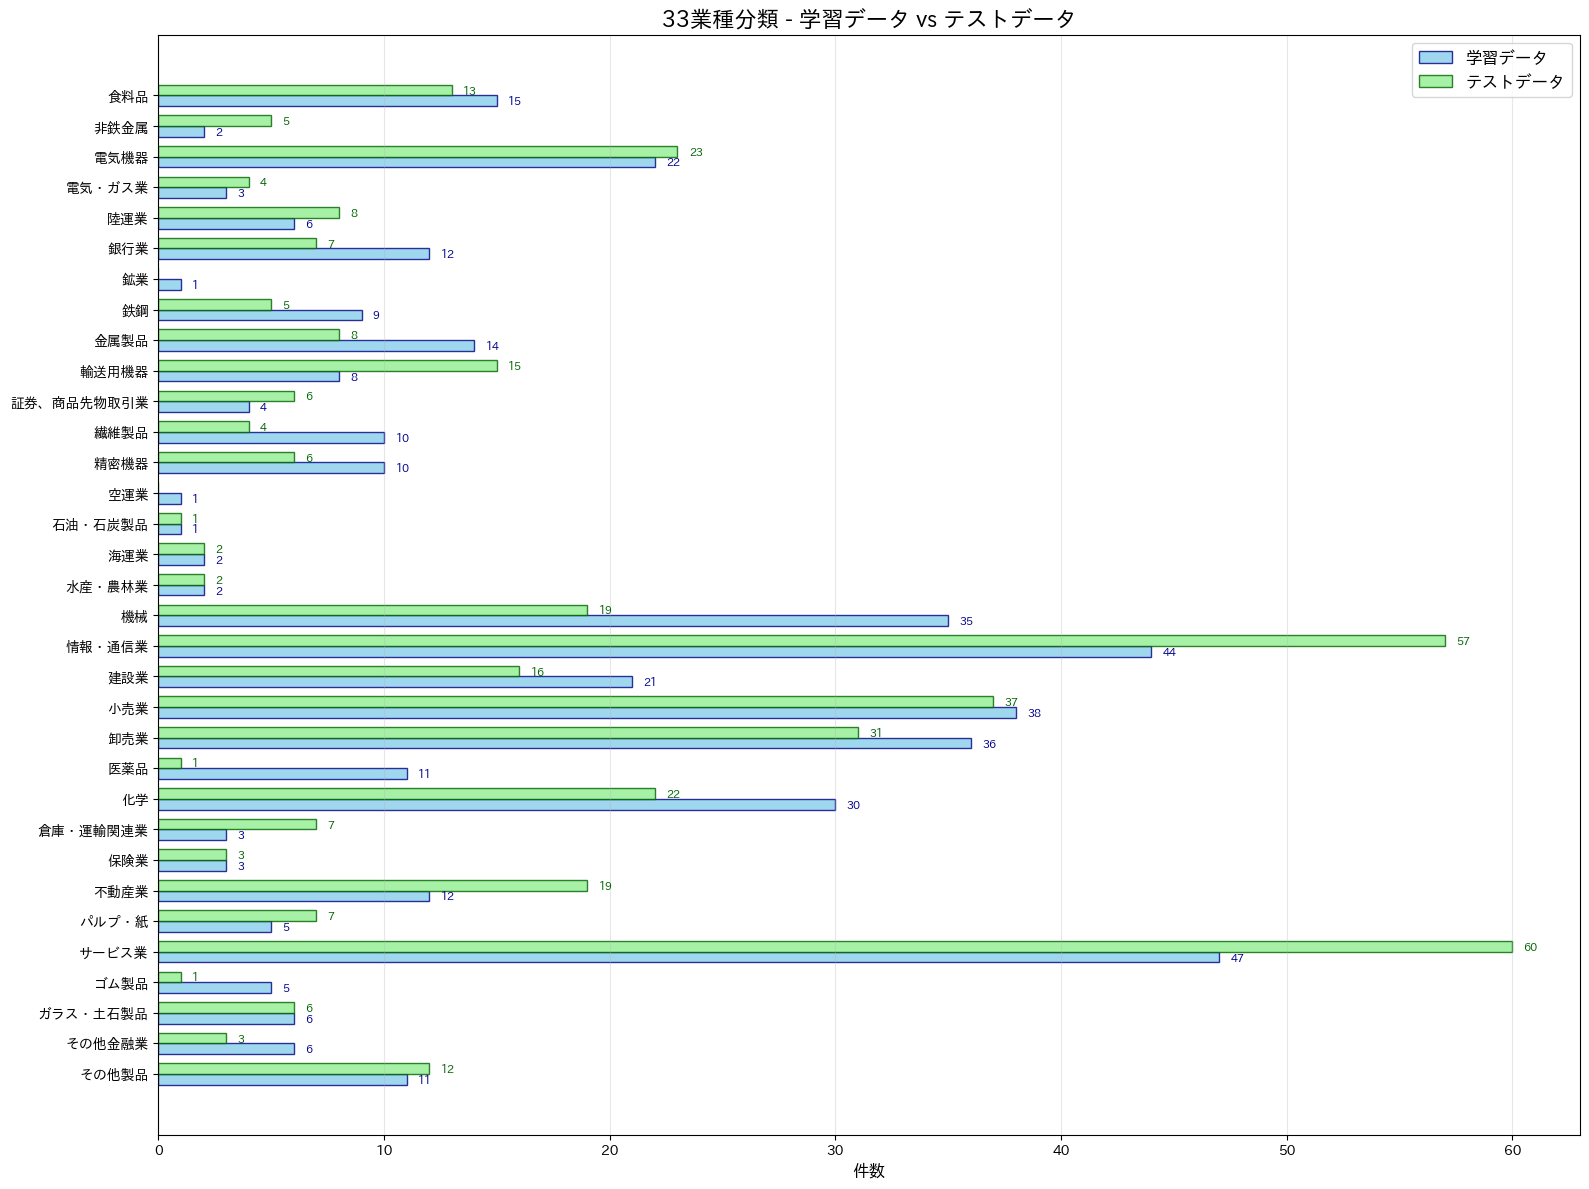

=== 33業種分類 上位10業種 ===
    33業種区分  学習データ件数  テストデータ件数  合計件数
4    サービス業       47        60   107
14  情報・通信業       44        57   101
12     小売業       38        37    75
11     卸売業       36        31    67
15      機械       35        19    54
9       化学       30        22    52
30    電気機器       22        23    45
13     建設業       21        16    37
6     不動産業       12        19    31
32     食料品       15        13    28


In [17]:
# 33業種分類の学習・テストデータの同時比較
fig, ax = plt.subplots(figsize=(16, 12))

y_pos = np.arange(len(all_industries33))
bar_width = 0.35

# 学習データとテストデータのバーを並べて表示
bars1 = ax.barh(y_pos - bar_width/2, train_counts33, bar_width, 
                label='学習データ', color='skyblue', edgecolor='navy', alpha=0.8)
bars2 = ax.barh(y_pos + bar_width/2, test_counts33, bar_width,
                label='テストデータ', color='lightgreen', edgecolor='darkgreen', alpha=0.8)

ax.set_title('33業種分類 - 学習データ vs テストデータ', fontsize=16, fontweight='bold')
ax.set_xlabel('件数', fontsize=12)
ax.set_yticks(y_pos)
ax.set_yticklabels(all_industries33, fontsize=10)
ax.legend(fontsize=12)
ax.grid(axis='x', alpha=0.3)

# 件数を表示（重複しないように調整）
for i, (train_count, test_count) in enumerate(zip(train_counts33, test_counts33)):
    if train_count > 0:
        ax.text(train_count + 0.5, i - bar_width/2, f'{int(train_count)}', 
                ha='left', va='center', fontweight='bold', fontsize=8, color='darkblue')
    if test_count > 0:
        ax.text(test_count + 0.5, i + bar_width/2, f'{int(test_count)}', 
                ha='left', va='center', fontweight='bold', fontsize=8, color='darkgreen')

plt.tight_layout()
plt.show()

# 詳細統計
comparison_33 = pd.DataFrame({
    '33業種区分': all_industries33,
    '学習データ件数': train_counts33,
    'テストデータ件数': test_counts33,
    '合計件数': [t + s for t, s in zip(train_counts33, test_counts33)]
})

# 上位10業種を表示
top_industries = comparison_33.sort_values('合計件数', ascending=False).head(10)
print("=== 33業種分類 上位10業種 ===")
print(top_industries)

## 17. 17業種分類の可視化

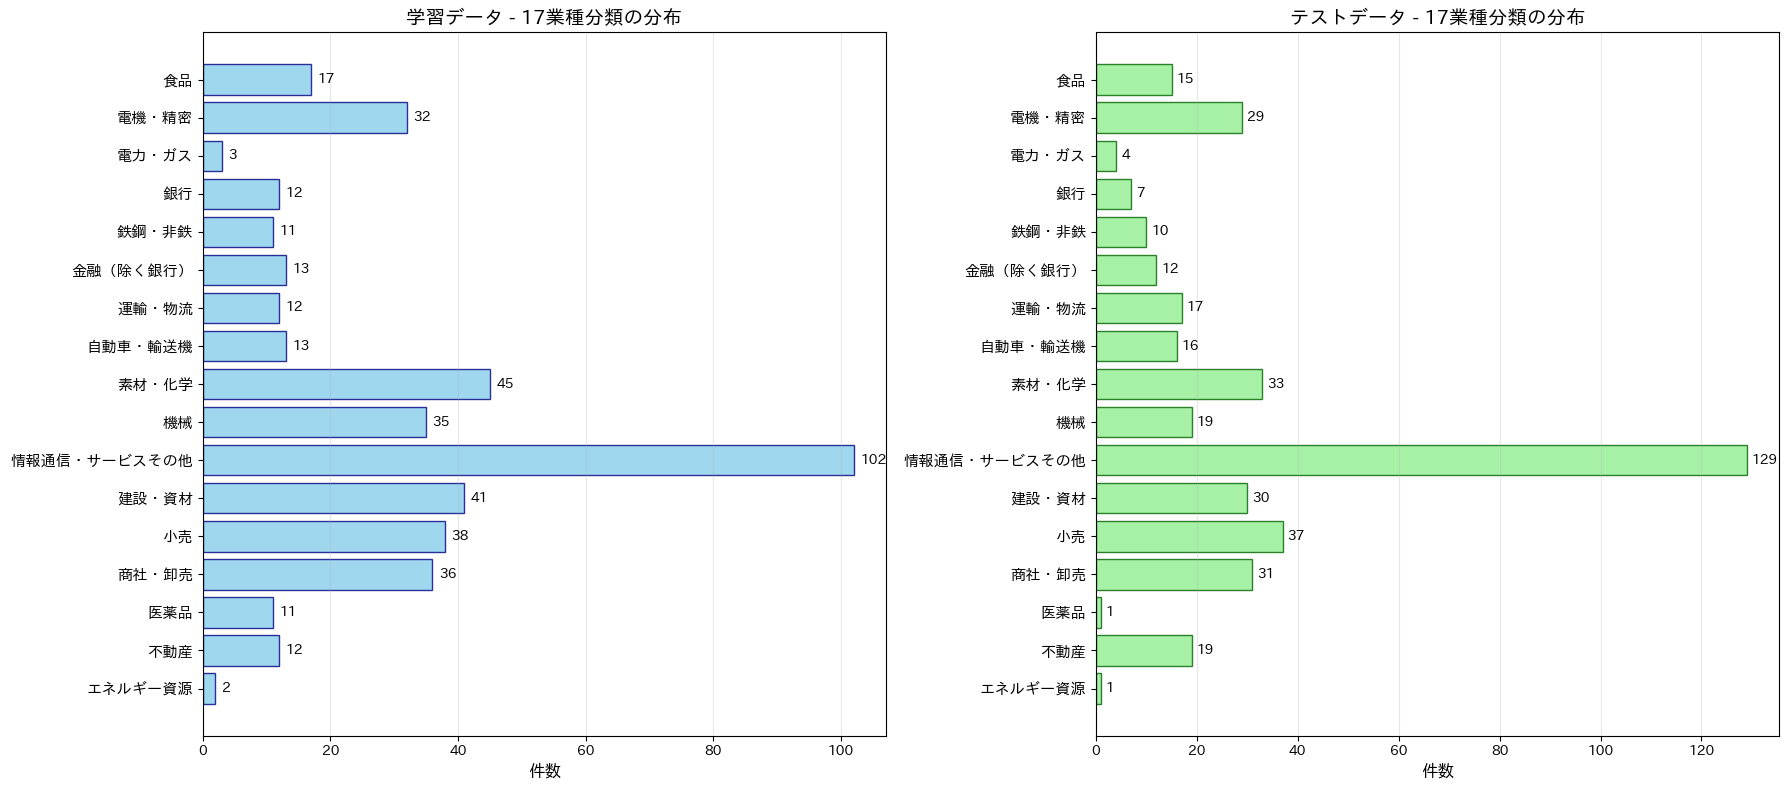

17業種分類の総数: 17種類
学習データに含まれる17業種数: 17種類
テストデータに含まれる17業種数: 17種類


In [18]:
# 17業種分類の件数集計
train_industry17 = df_train_full['17業種区分'].value_counts().fillna(0)
test_industry17 = df_test_full['17業種区分'].value_counts().fillna(0)

# 全ての業種を取得（学習・テスト両方含む）
all_industries17 = sorted(set(list(train_industry17.index) + list(test_industry17.index)))

# データを整形（存在しない業種は0で埋める）
train_counts17 = [train_industry17.get(industry, 0) for industry in all_industries17]
test_counts17 = [test_industry17.get(industry, 0) for industry in all_industries17]

# 17業種分類の比較グラフ作成
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# 学習データ
bars1 = ax1.barh(range(len(all_industries17)), train_counts17, color='skyblue', edgecolor='navy', alpha=0.8)
ax1.set_title('学習データ - 17業種分類の分布', fontsize=14, fontweight='bold')
ax1.set_xlabel('件数', fontsize=12)
ax1.set_yticks(range(len(all_industries17)))
ax1.set_yticklabels(all_industries17, fontsize=11)
ax1.grid(axis='x', alpha=0.3)

# 件数をバーの右側に表示
for i, bar in enumerate(bars1):
    width = bar.get_width()
    if width > 0:
        ax1.text(width + 1, bar.get_y() + bar.get_height()/2, 
                f'{int(width)}', ha='left', va='center', fontweight='bold', fontsize=10)

# テストデータ
bars2 = ax2.barh(range(len(all_industries17)), test_counts17, color='lightgreen', edgecolor='darkgreen', alpha=0.8)
ax2.set_title('テストデータ - 17業種分類の分布', fontsize=14, fontweight='bold')
ax2.set_xlabel('件数', fontsize=12)
ax2.set_yticks(range(len(all_industries17)))
ax2.set_yticklabels(all_industries17, fontsize=11)
ax2.grid(axis='x', alpha=0.3)

# 件数をバーの右側に表示
for i, bar in enumerate(bars2):
    width = bar.get_width()
    if width > 0:
        ax2.text(width + 1, bar.get_y() + bar.get_height()/2, 
                f'{int(width)}', ha='left', va='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

print(f"17業種分類の総数: {len(all_industries17)}種類")
print(f"学習データに含まれる17業種数: {len([x for x in train_counts17 if x > 0])}種類")
print(f"テストデータに含まれる17業種数: {len([x for x in test_counts17 if x > 0])}種類")

## 18. 17業種分類の学習・テストデータ比較（件数と割合）

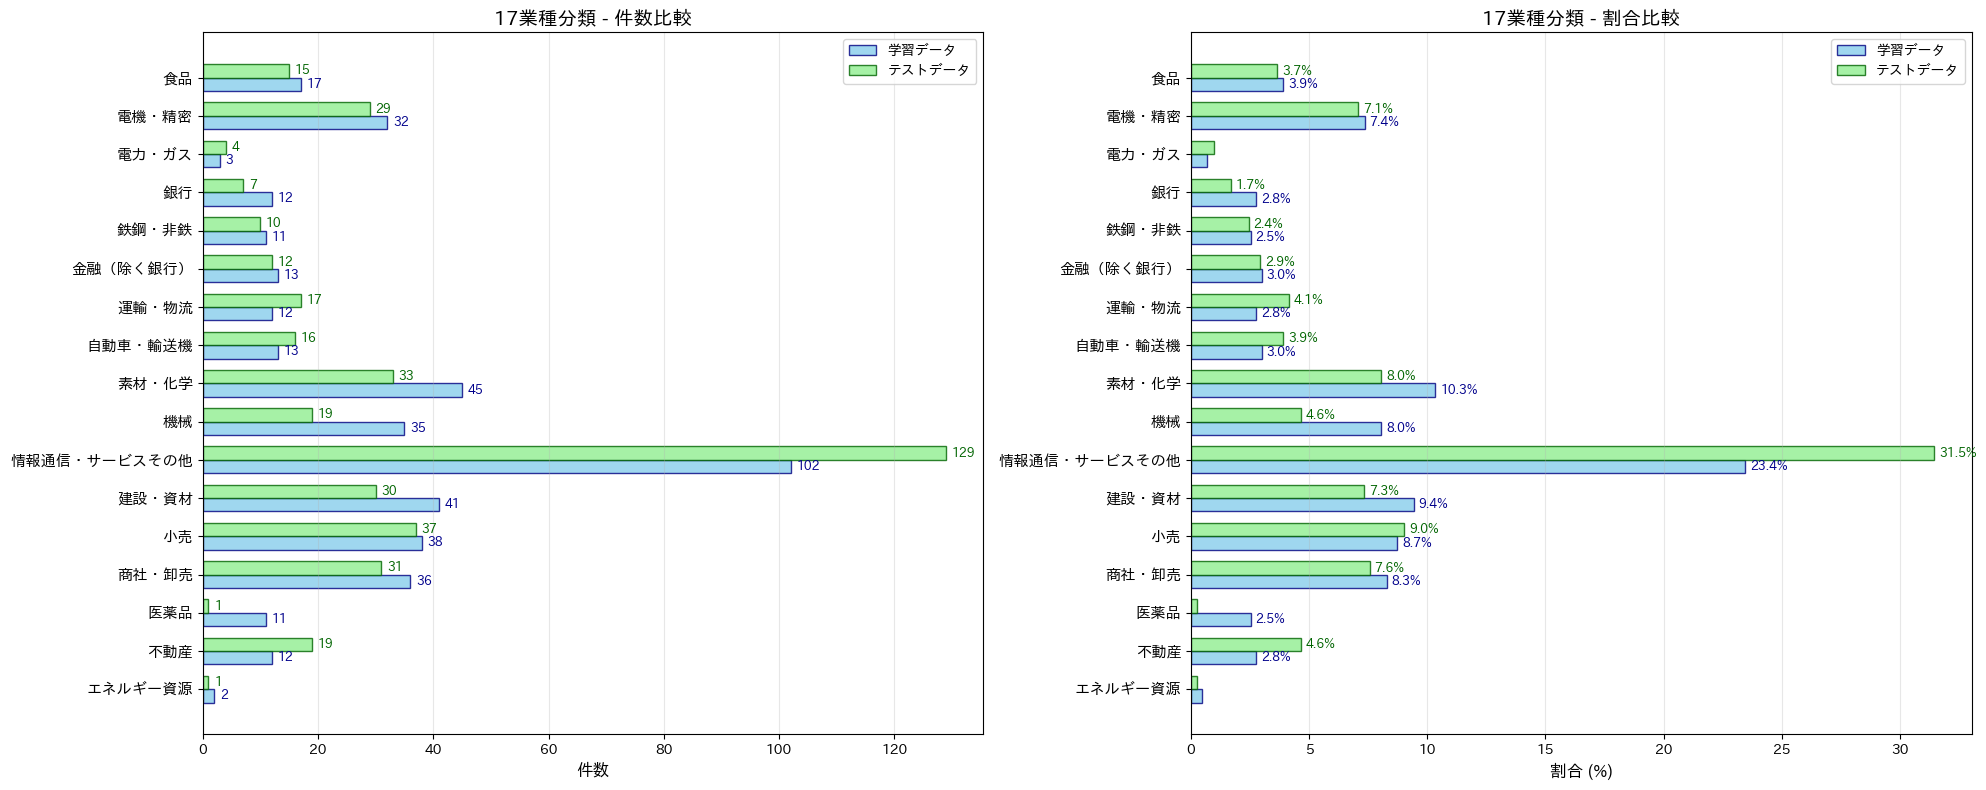

=== 17業種分類 詳細統計 ===
          17業種区分  学習データ件数 学習データ割合(%)  テストデータ件数 テストデータ割合(%)  合計件数
6   情報通信・サービスその他      102       23.4       129        31.5   231
8          素材・化学       45       10.3        33         8.0    78
4             小売       38        8.7        37         9.0    75
5          建設・資材       41        9.4        30         7.3    71
3          商社・卸売       36        8.3        31         7.6    67
15         電機・精密       32        7.4        29         7.1    61
7             機械       35        8.0        19         4.6    54
16            食品       17        3.9        15         3.7    32
1            不動産       12        2.8        19         4.6    31
9        自動車・輸送機       13        3.0        16         3.9    29
10         運輸・物流       12        2.8        17         4.1    29
11      金融（除く銀行）       13        3.0        12         2.9    25
12         鉄鋼・非鉄       11        2.5        10         2.4    21
13            銀行       12        2.8         7         1.7    19
2    

In [19]:
# 17業種分類の学習・テストデータの同時比較（件数と割合）
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

y_pos = np.arange(len(all_industries17))
bar_width = 0.35

# 件数の比較
bars1 = ax1.barh(y_pos - bar_width/2, train_counts17, bar_width, 
                label='学習データ', color='skyblue', edgecolor='navy', alpha=0.8)
bars2 = ax1.barh(y_pos + bar_width/2, test_counts17, bar_width,
                label='テストデータ', color='lightgreen', edgecolor='darkgreen', alpha=0.8)

ax1.set_title('17業種分類 - 件数比較', fontsize=14, fontweight='bold')
ax1.set_xlabel('件数', fontsize=12)
ax1.set_yticks(y_pos)
ax1.set_yticklabels(all_industries17, fontsize=11)
ax1.legend(fontsize=10)
ax1.grid(axis='x', alpha=0.3)

# 件数を表示
for i, (train_count, test_count) in enumerate(zip(train_counts17, test_counts17)):
    if train_count > 0:
        ax1.text(train_count + 1, i - bar_width/2, f'{int(train_count)}', 
                ha='left', va='center', fontweight='bold', fontsize=9, color='darkblue')
    if test_count > 0:
        ax1.text(test_count + 1, i + bar_width/2, f'{int(test_count)}', 
                ha='left', va='center', fontweight='bold', fontsize=9, color='darkgreen')

# 割合の計算と比較
train_total = sum(train_counts17)
test_total = sum(test_counts17)
train_percentages = [(count/train_total)*100 for count in train_counts17]
test_percentages = [(count/test_total)*100 for count in test_counts17]

bars3 = ax2.barh(y_pos - bar_width/2, train_percentages, bar_width, 
                label='学習データ', color='skyblue', edgecolor='navy', alpha=0.8)
bars4 = ax2.barh(y_pos + bar_width/2, test_percentages, bar_width,
                label='テストデータ', color='lightgreen', edgecolor='darkgreen', alpha=0.8)

ax2.set_title('17業種分類 - 割合比較', fontsize=14, fontweight='bold')
ax2.set_xlabel('割合 (%)', fontsize=12)
ax2.set_yticks(y_pos)
ax2.set_yticklabels(all_industries17, fontsize=11)
ax2.legend(fontsize=10)
ax2.grid(axis='x', alpha=0.3)

# 割合を表示（1%以上のもののみ）
for i, (train_pct, test_pct) in enumerate(zip(train_percentages, test_percentages)):
    if train_pct >= 1.0:
        ax2.text(train_pct + 0.2, i - bar_width/2, f'{train_pct:.1f}%', 
                ha='left', va='center', fontweight='bold', fontsize=9, color='darkblue')
    if test_pct >= 1.0:
        ax2.text(test_pct + 0.2, i + bar_width/2, f'{test_pct:.1f}%', 
                ha='left', va='center', fontweight='bold', fontsize=9, color='darkgreen')

plt.tight_layout()
plt.show()

# 詳細統計テーブル
comparison_17 = pd.DataFrame({
    '17業種区分': all_industries17,
    '学習データ件数': train_counts17,
    '学習データ割合(%)': [f'{pct:.1f}' for pct in train_percentages],
    'テストデータ件数': test_counts17,
    'テストデータ割合(%)': [f'{pct:.1f}' for pct in test_percentages],
    '合計件数': [t + s for t, s in zip(train_counts17, test_counts17)]
})

# 全業種の統計を表示
print("=== 17業種分類 詳細統計 ===")
print(comparison_17.sort_values('合計件数', ascending=False))

print(f"\n=== サマリー ===")
print(f"学習データ総件数: {train_total}")
print(f"テストデータ総件数: {test_total}")
print(f"全体総件数: {train_total + test_total}")

## 19. 17業種分類の円グラフ表示

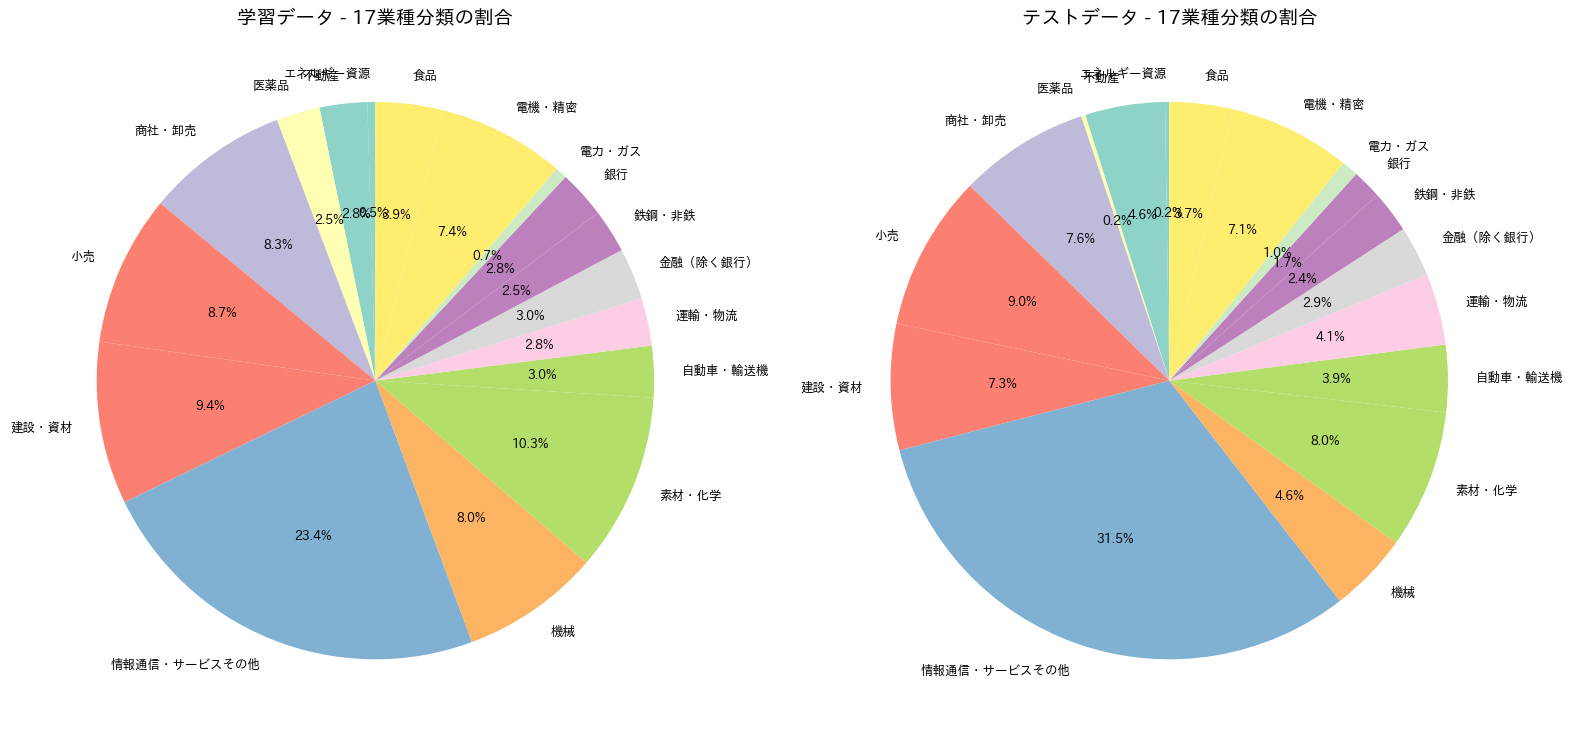

In [21]:
# 17業種分類の円グラフ表示
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# 学習データの円グラフ
train_valid_data = [(industry, count) for industry, count in zip(all_industries17, train_counts17) if count > 0]
train_labels, train_sizes = zip(*train_valid_data) if train_valid_data else ([], [])

if train_sizes:
    colors1 = plt.cm.Set3(np.linspace(0, 1, len(train_sizes)))
    wedges1, texts1, autotexts1 = ax1.pie(train_sizes, labels=train_labels, autopct='%1.1f%%', 
                                          startangle=90, colors=colors1, textprops={'fontsize': 9})
    ax1.set_title('学習データ - 17業種分類の割合', fontsize=14, fontweight='bold')

# テストデータの円グラフ
test_valid_data = [(industry, count) for industry, count in zip(all_industries17, test_counts17) if count > 0]
test_labels, test_sizes = zip(*test_valid_data) if test_valid_data else ([], [])

if test_sizes:
    colors2 = plt.cm.Set3(np.linspace(0, 1, len(test_sizes)))
    wedges2, texts2, autotexts2 = ax2.pie(test_sizes, labels=test_labels, autopct='%1.1f%%', 
                                          startangle=90, colors=colors2, textprops={'fontsize': 9})
    ax2.set_title('テストデータ - 17業種分類の割合', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

In [22]:
# 業種分類の分析結果サマリー
print("=== 業種分類分析結果サマリー ===")
print(f"33業種分類:")
print(f"  - 学習データに含まれる業種数: {len([x for x in train_counts33 if x > 0])}/{len(all_industries33)}")
print(f"  - テストデータに含まれる業種数: {len([x for x in test_counts33 if x > 0])}/{len(all_industries33)}")

print(f"\n17業種分類:")
print(f"  - 学習データに含まれる業種数: {len([x for x in train_counts17 if x > 0])}/{len(all_industries17)}")
print(f"  - テストデータに含まれる業種数: {len([x for x in test_counts17 if x > 0])}/{len(all_industries17)}")

print(f"\nデータ件数:")
print(f"  - 学習データ: {train_total}件")
print(f"  - テストデータ: {test_total}件")
print(f"  - 合計: {train_total + test_total}件")

print("\n" + "="*80)

# 17業種分類の構成比まとめ
print("\n=== 17業種分類 構成比まとめ ===")
composition_17 = pd.DataFrame({
    '業種区分': all_industries17,
    '学習データ件数': train_counts17,
    '学習データ構成比(%)': [f'{(count/train_total)*100:.1f}' for count in train_counts17],
    'テストデータ件数': test_counts17,
    'テストデータ構成比(%)': [f'{(count/test_total)*100:.1f}' for count in test_counts17],
    '全体件数': [t + s for t, s in zip(train_counts17, test_counts17)],
    '全体構成比(%)': [f'{((t + s)/(train_total + test_total))*100:.1f}' for t, s in zip(train_counts17, test_counts17)]
})

# 0件のものを除外して表示
composition_17_filtered = composition_17[composition_17['全体件数'] > 0].sort_values('全体件数', ascending=False)
print(composition_17_filtered)

print("\n" + "="*80)

# 33業種分類の構成比まとめ
print("\n=== 33業種分類 構成比まとめ ===")
composition_33 = pd.DataFrame({
    '業種区分': all_industries33,
    '学習データ件数': train_counts33,
    '学習データ構成比(%)': [f'{(count/train_total)*100:.1f}' for count in train_counts33],
    'テストデータ件数': test_counts33,
    'テストデータ構成比(%)': [f'{(count/test_total)*100:.1f}' for count in test_counts33],
    '全体件数': [t + s for t, s in zip(train_counts33, test_counts33)],
    '全体構成比(%)': [f'{((t + s)/(train_total + test_total))*100:.1f}' for t, s in zip(train_counts33, test_counts33)]
})

# 0件のものを除外して表示
composition_33_filtered = composition_33[composition_33['全体件数'] > 0].sort_values('全体件数', ascending=False)
print(composition_33_filtered)

print("\n" + "="*80)
print("=== データ出力完了 ===")
print(f"17業種分類データフレーム: composition_17_filtered")
print(f"33業種分類データフレーム: composition_33_filtered")

=== 業種分類分析結果サマリー ===
33業種分類:
  - 学習データに含まれる業種数: 33/33
  - テストデータに含まれる業種数: 31/33

17業種分類:
  - 学習データに含まれる業種数: 17/17
  - テストデータに含まれる業種数: 17/17

データ件数:
  - 学習データ: 435件
  - テストデータ: 410件
  - 合計: 845件


=== 17業種分類 構成比まとめ ===
            業種区分  学習データ件数 学習データ構成比(%)  テストデータ件数 テストデータ構成比(%)  全体件数 全体構成比(%)
6   情報通信・サービスその他      102        23.4       129         31.5   231     27.3
8          素材・化学       45        10.3        33          8.0    78      9.2
4             小売       38         8.7        37          9.0    75      8.9
5          建設・資材       41         9.4        30          7.3    71      8.4
3          商社・卸売       36         8.3        31          7.6    67      7.9
15         電機・精密       32         7.4        29          7.1    61      7.2
7             機械       35         8.0        19          4.6    54      6.4
16            食品       17         3.9        15          3.7    32      3.8
1            不動産       12         2.8        19          4.6    31      3.7
9        自動車・輸送機      

In [24]:
composition_17

,業種区分,学習データ件数,学習データ構成比(%),テストデータ件数,テストデータ構成比(%),全体件数,全体構成比(%)
0,エネルギー資源,2,0.5,1,0.2,3,0.4
1,不動産,12,2.8,19,4.6,31,3.7
2,医薬品,11,2.5,1,0.2,12,1.4
3,商社・卸売,36,8.3,31,7.6,67,7.9
4,小売,38,8.7,37,9.0,75,8.9
5,建設・資材,41,9.4,30,7.3,71,8.4
6,情報通信・サービスその他,102,23.4,129,31.5,231,27.3
7,機械,35,8.0,19,4.6,54,6.4
8,素材・化学,45,10.3,33,8.0,78,9.2
9,自動車・輸送機,13,3.0,16,3.9,29,3.4


In [23]:
composition_33

,業種区分,学習データ件数,学習データ構成比(%),テストデータ件数,テストデータ構成比(%),全体件数,全体構成比(%)
0,その他製品,11,2.5,12,2.9,23,2.7
1,その他金融業,6,1.4,3,0.7,9,1.1
2,ガラス・土石製品,6,1.4,6,1.5,12,1.4
3,ゴム製品,5,1.1,1,0.2,6,0.7
4,サービス業,47,10.8,60,14.6,107,12.7
5,パルプ・紙,5,1.1,7,1.7,12,1.4
6,不動産業,12,2.8,19,4.6,31,3.7
7,保険業,3,0.7,3,0.7,6,0.7
8,倉庫・運輸関連業,3,0.7,7,1.7,10,1.2
9,化学,30,6.9,22,5.4,52,6.2
